In [131]:
#data diri
#Nama: Era Syafina
#dataset : https://www.kaggle.com/datasets/balabaskar/bitcoin-news-articles-text-corpora

In [132]:
import pandas as pd
df = pd.read_csv('/content/bitcoin_articles.csv')

In [133]:
df = df.drop(columns=[
    'author', 'title', 'authors', 'country', 'language', 'excerpt',
    'article_id', 'published_date', 'link', 'clean_url', 'rights',
    'article_rank', 'media', 'twitter_account', 'article_score'
])

In [134]:
df.head()

,summary,topic
0,"Over the course of the last few years, there h...",finance
1,Russia Legalizing Bitcoin And Crypto Is A Matt...,news
2,Bitcoin has a maximum supply of 21 million. Ho...,news
3,"Conceived in 2008 and launched in 2009, bitcoi...",business
4,Bear markets are for building out capacity on ...,news


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   summary  2473 non-null   object
 1   topic    2500 non-null   object
dtypes: object(2)
memory usage: 39.2+ KB


In [136]:
kategory = pd.get_dummies(df.topic)

new_df = pd.concat([df, kategory], axis=1)
new_df = new_df.drop(columns=['topic'])
new_df['summary']= new_df['summary'].fillna('').apply(str)

new_df.head()

,summary,beauty,business,economics,energy,entertainment,finance,food,news,politics,science,sport,tech,world
0,"Over the course of the last few years, there h...",0,0,0,0,0,1,0,0,0,0,0,0,0
1,Russia Legalizing Bitcoin And Crypto Is A Matt...,0,0,0,0,0,0,0,1,0,0,0,0,0
2,Bitcoin has a maximum supply of 21 million. Ho...,0,0,0,0,0,0,0,1,0,0,0,0,0
3,"Conceived in 2008 and launched in 2009, bitcoi...",0,1,0,0,0,0,0,0,0,0,0,0,0
4,Bear markets are for building out capacity on ...,0,0,0,0,0,0,0,1,0,0,0,0,0


In [137]:
df['topic'].value_counts()

news             1985
finance           388
business           79
tech               20
economics          11
world               6
entertainment       3
science             2
beauty              2
politics            1
sport               1
food                1
energy              1
Name: topic, dtype: int64

In [138]:
summary = new_df['summary'].values
label = new_df[[
    'beauty', 'business', 'economics',
    'energy', 'entertainment',
    'finance', 'food', 'news',
    'politics', 'science', 'sport',
    'tech', 'world'
]].values

In [139]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("popular")

index = 0
while index < len(summary):
    tokenizer = nltk.RegexpTokenizer(r"\w+")
    new_words = tokenizer.tokenize(str(summary[index]))
    new_words = " ".join(new_words)

    stop_words = set(stopwords.words('english'))
    tokenizer = nltk.RegexpTokenizer(r"\w+")
    word_tokens = tokenizer.tokenize(new_words)
    filtered_sentence = [w for w in word_tokens if w.lower() not in stop_words]
    summary[index] = " ".join(filtered_sentence)

    index += 1

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to-date!
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Package names is already up-to-date!
[nltk_data]    | Do

In [140]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(summary, label, test_size=0.2)

In [141]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000, oov_token='')
tokenizer.fit_on_texts(data_train)

sekuens_train = tokenizer.texts_to_sequences(data_train)
sekuens_test = tokenizer.texts_to_sequences(data_test)

padded_train = pad_sequences(sekuens_train)
padded_test = pad_sequences(sekuens_test)

In [142]:
import tensorflow as tf

class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs = {}):
    if(logs.get('val_accuracy') > 0.81):
      print("\n accuracy model sudah > 81")
      self.model.stop_training = True

callbacks = myCallback()

In [143]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=5000, output_dim=100),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(526, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(13, activation='softmax')
])

In [144]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_8 (Embedding)     (None, None, 100)         500000    
                                                                 
 lstm_8 (LSTM)               (None, 64)                42240     
                                                                 
 dropout_8 (Dropout)         (None, 64)                0         
                                                                 
 dense_32 (Dense)            (None, 128)               8320      
                                                                 
 dense_33 (Dense)            (None, 526)               67854     
                                                                 
 dense_34 (Dense)            (None, 256)               134912    
                                                                 
 dense_35 (Dense)            (None, 13)               

In [145]:
num_epochs = 50

history = model.fit(
    padded_train, target_train,
    steps_per_epoch = 10,
    epochs=num_epochs,
    validation_data=(padded_test, target_test),
    batch_size=32,
    validation_steps = 10,
    verbose=2,
    callbacks = [callbacks]
)

Epoch 1/50
10/10 - 6s - loss: 2.3013 - accuracy: 0.6969 - val_loss: 1.4879 - val_accuracy: 0.7969 - 6s/epoch - 598ms/step
Epoch 2/50
10/10 - 1s - loss: 0.9151 - accuracy: 0.7969 - val_loss: 0.6407 - val_accuracy: 0.7969 - 1s/epoch - 117ms/step
Epoch 3/50
10/10 - 1s - loss: 0.7642 - accuracy: 0.8062 - val_loss: 0.6286 - val_accuracy: 0.7969 - 1s/epoch - 115ms/step
Epoch 4/50
10/10 - 1s - loss: 0.7502 - accuracy: 0.7812 - val_loss: 0.6254 - val_accuracy: 0.7969 - 1s/epoch - 118ms/step
Epoch 5/50
10/10 - 1s - loss: 0.6776 - accuracy: 0.7969 - val_loss: 0.6000 - val_accuracy: 0.7969 - 1s/epoch - 118ms/step
Epoch 6/50
10/10 - 1s - loss: 0.6119 - accuracy: 0.7937 - val_loss: 0.5596 - val_accuracy: 0.7969 - 1s/epoch - 116ms/step
Epoch 7/50

 accuracy model sudah > 81
10/10 - 1s - loss: 0.4791 - accuracy: 0.8355 - val_loss: 0.5182 - val_accuracy: 0.8219 - 1s/epoch - 115ms/step


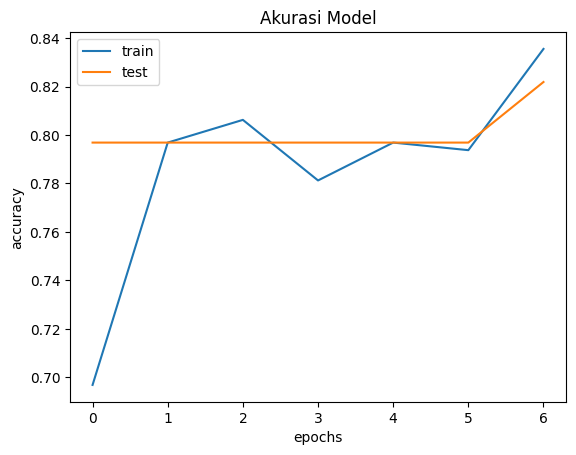

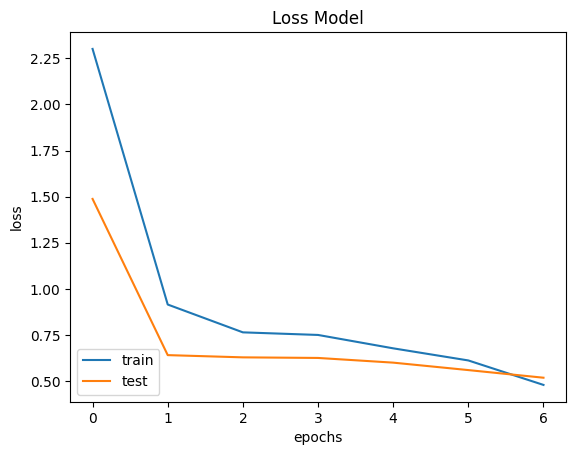

In [146]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Akurasi Model')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

print('\n')

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Model')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(['train', 'test'], loc='lower left')
plt.show()